# GATE full-feature ablation (lr $5\times10^{-6}$)

Comparison of the original two-layer GAT and the four-layer residual GAT on the
`full_feature_ablation_lr5e-6` sweep. Every run already carries the full base node-feature
set (`aa_type`, `chain`, `interface_nodes`, `rsasa_i`); the ablation then adds
`interface_node_degree` (a node feature) and `voronoi_contact_area` (an *edge* feature),
cumulatively from left to right. Six runs in total: 2 architectures $\times$ 3 feature cases.

DockQ RMSE is pooled across all held-out model predictions; missing or incomplete runs
remain missing rather than being assigned zero. In addition to the DockQ head, these runs
also export autoencoder reconstruction metrics, which are analysed in the final section.

In [1]:
from pathlib import Path
import shutil

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "text.usetex": shutil.which("latex") is not None,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

TEX = mpl.rcParams["text.usetex"]
PCT = r"\%" if TEX else "%"
ANGSTROM = r"\AA" if TEX else "Å"

def tex_safe(text):
    """Escape characters that LaTeX would otherwise swallow."""
    return text.replace("_", r"\_").replace("%", r"\%") if TEX else text

candidates = [
    Path.cwd() / "full_feature_ablation_lr5e-6",
    Path.cwd() / "gate_run" / "full_feature_ablation_lr5e-6",
    Path.cwd(),
]
RUN_DIR = next((p.resolve() for p in candidates if any(p.glob("gat2_*/loss_history.csv"))), None)
if RUN_DIR is None:
    raise FileNotFoundError("Could not locate full_feature_ablation_lr5e-6")
FIGURE_DIR = RUN_DIR / "analysis_figures"
FIGURE_DIR.mkdir(exist_ok=True)
print(f"Run directory: {RUN_DIR}")
print(f"LaTeX rendering: {TEX}")

Run directory: /Users/jakesumner/Documents/GitHub/PPI-graph_autoencoder/gate_run/full_feature_ablation_lr5e-6
LaTeX rendering: True


## Runs, feature sets and headline DockQ metrics

In [2]:
STAGES = [
    ("01_rsasa_i", "Base\n" + (r"($r$SASA$_i$)")),
    ("02_plus_interface_node_degree", "+ Interface-node\ndegree"),
    ("03_plus_voronoi_contact_area", "+ Voronoi\ncontact area"),
]
ARCHITECTURES = [
    ("gat2", "2-layer GAT", "black"),
    ("gat4_residual", "4-layer residual GAT", "lightgray"),
]

prediction_frames = {}
history_frames = {}
recon_summary_frames = {}
recon_target_frames = {}
records = []
for arch_key, arch_label, _ in ARCHITECTURES:
    for stage_index, (stage_key, stage_label) in enumerate(STAGES, start=1):
        run_name = f"{arch_key}_{stage_key}"
        run_dir = RUN_DIR / run_name
        prediction_path = run_dir / "test_predictions.csv"
        history_path = run_dir / "loss_history.csv"
        summary_path = run_dir / "reconstruction_summary.csv"
        by_target_path = run_dir / "reconstruction_by_target.csv"
        if history_path.is_file():
            history_frames[run_name] = pd.read_csv(history_path)
        if summary_path.is_file():
            recon_summary_frames[run_name] = pd.read_csv(summary_path)
        if by_target_path.is_file():
            recon_target_frames[run_name] = pd.read_csv(by_target_path)
        base = {
            "architecture": arch_label, "architecture_key": arch_key,
            "stage": stage_index, "feature_case": stage_label, "run_name": run_name,
        }
        if prediction_path.is_file():
            frame = pd.read_csv(prediction_path)
            prediction_frames[run_name] = frame
            error = frame["predicted_target"] - frame["true_target"]
            per_target_rmse = frame.assign(sq_error=error**2).groupby("target_id")["sq_error"].mean().pow(0.5)
            records.append({
                **base,
                "models": len(frame), "targets": frame["target_id"].nunique(),
                "RMSE": np.sqrt(np.mean(error**2)), "MAE": np.mean(np.abs(error)),
                "mean_target_RMSE": per_target_rmse.mean(),
                "Pearson_r": frame["true_target"].corr(frame["predicted_target"]),
                "Spearman_rho": frame["true_target"].corr(frame["predicted_target"], method="spearman"),
                "status": "complete",
            })
        else:
            records.append({
                **base,
                "models": 0, "targets": 0, "RMSE": np.nan, "MAE": np.nan,
                "mean_target_RMSE": np.nan, "Pearson_r": np.nan, "Spearman_rho": np.nan,
                "status": "incomplete: no test_predictions.csv",
            })
metrics = pd.DataFrame(records)

feature_rows = []
for stage_index, (stage_key, stage_label) in enumerate(STAGES, start=1):
    summary = recon_summary_frames.get(f"gat2_{stage_key}")
    feature_rows.append({
        "stage": stage_index,
        "feature_case": stage_label.replace("\n", " "),
        "node_features": summary["node_features"].iloc[0] if summary is not None else "---",
        "edge_features": summary["edge_features"].iloc[0] if summary is not None else "---",
    })
print("Cumulative feature composition (identical for both architectures):")
display(pd.DataFrame(feature_rows).set_index("stage"))

display(metrics.drop(columns=["architecture_key", "run_name"]).style.format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "mean_target_RMSE": "{:.4f}",
    "Pearson_r": "{:.4f}", "Spearman_rho": "{:.4f}",
}, na_rep="---"))

Cumulative feature composition (identical for both architectures):


,feature_case,node_features,edge_features
stage,,,
1,Base ($r$SASA$_i$),"aa_type,chain,interface_nodes,rsasa_i","interface_edges,ca_dist"
2,+ Interface-node degree,"aa_type,chain,interface_nodes,rsasa_i,interfac...","interface_edges,ca_dist"
3,+ Voronoi contact area,"aa_type,chain,interface_nodes,rsasa_i,interfac...","interface_edges,ca_dist,voronoi_contact_area"


,architecture,stage,feature_case,models,targets,RMSE,MAE,mean_target_RMSE,Pearson_r,Spearman_rho,status
0,2-layer GAT,1,Base ($r$SASA$_i$),30466,25,0.2642,0.1993,0.2535,0.5700,0.5881,complete
1,2-layer GAT,2,+ Interface-node degree,30466,25,0.2667,0.1974,0.2541,0.5665,0.5592,complete
2,2-layer GAT,3,+ Voronoi contact area,30466,25,0.2833,0.2184,0.2760,0.5021,0.5152,complete
3,4-layer residual GAT,1,Base ($r$SASA$_i$),30466,25,0.2468,0.1789,0.2357,0.6351,0.6524,complete
4,4-layer residual GAT,2,+ Interface-node degree,30466,25,0.2728,0.1912,0.2546,0.6025,0.5689,complete
5,4-layer residual GAT,3,+ Voronoi contact area,30466,25,0.2548,0.1967,0.2459,0.5881,0.6110,complete


## Observed versus predicted DockQ for all test targets

Choose any completed run below. All 25 panels use common axes, and each title reports the
target sample count and Spearman rank correlation. The final loop also exports an
equivalent PDF for every completed run.

findfont: Failed to find font weight normal for CMU Serif, now using 500.


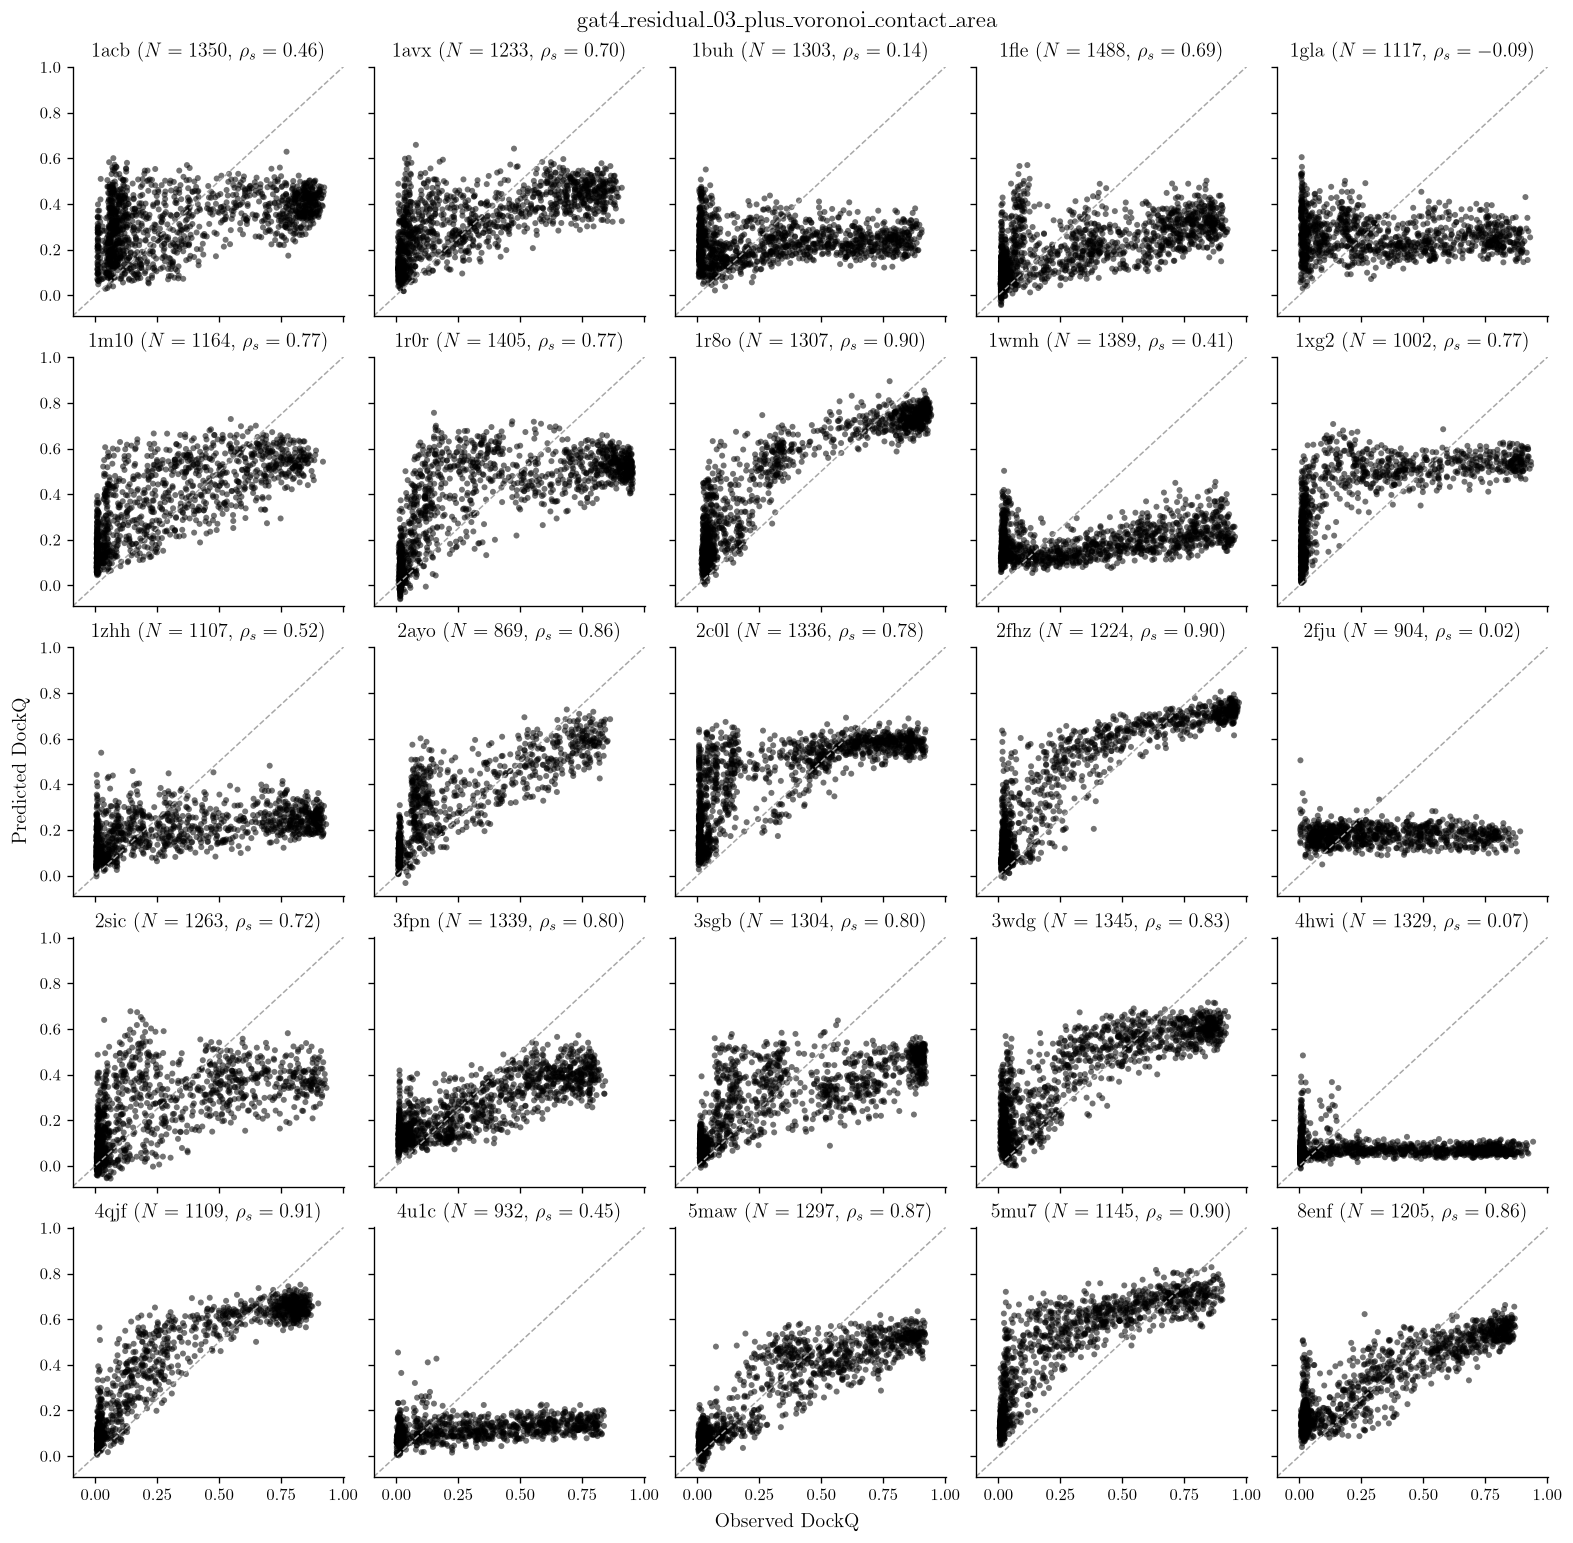

Exported 6 completed-run target panels to /Users/jakesumner/Documents/GitHub/PPI-graph_autoencoder/gate_run/full_feature_ablation_lr5e-6/analysis_figures


In [3]:
SELECTED_RUN = "gat4_residual_03_plus_voronoi_contact_area"

def plot_predictions_by_target(run_name, *, save=True, show=True):
    if run_name not in prediction_frames:
        available = "\n  ".join(sorted(prediction_frames))
        raise KeyError(f"No completed predictions for {run_name!r}. Available runs:\n  {available}")
    frame = prediction_frames[run_name]
    target_names = sorted(frame["target_id"].unique())
    ncols = 5
    nrows = int(np.ceil(len(target_names) / ncols))
    axis_min = min(frame["true_target"].min(), frame["predicted_target"].min())
    axis_max = max(frame["true_target"].max(), frame["predicted_target"].max())
    padding = 0.03 * (axis_max - axis_min)
    limits = (axis_min - padding, axis_max + padding)

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 2.55 * nrows), sharex=True, sharey=True, constrained_layout=True)
    for ax, target_id in zip(np.atleast_1d(axes).flat, target_names):
        target = frame.loc[frame["target_id"] == target_id]
        rho = target["true_target"].corr(target["predicted_target"], method="spearman")
        ax.scatter(target["true_target"], target["predicted_target"], s=13, alpha=0.55, color="black", edgecolors="none")
        ax.plot(limits, limits, color="0.65", ls="--", lw=0.9)
        ax.set(xlim=limits, ylim=limits, title=rf"{tex_safe(str(target_id))}  ($N={len(target)}$, $\rho_s={rho:.2f}$)")
    for ax in list(np.atleast_1d(axes).flat)[len(target_names):]:
        ax.set_visible(False)
    fig.supxlabel("Observed DockQ")
    fig.supylabel("Predicted DockQ")
    fig.suptitle(tex_safe(run_name), fontsize=14)
    if save:
        fig.savefig(FIGURE_DIR / f"dockq_by_target_{run_name}.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

plot_predictions_by_target(SELECTED_RUN)

for run_name in sorted(prediction_frames):
    if run_name != SELECTED_RUN:
        plot_predictions_by_target(run_name, save=True, show=False)
print(f"Exported {len(prediction_frames)} completed-run target panels to {FIGURE_DIR}")

### Best-performing run: 4-layer residual GAT on the base feature set

Of the six runs, `gat4_residual_01_rsasa_i` has both the lowest pooled DockQ RMSE and the
highest Spearman correlation, so the same 25-panel view is repeated for it below. Reading it
against the panels above isolates, target by target, what the two extra features cost.

Lowest pooled RMSE:   gat4_residual_01_rsasa_i
Highest Spearman rho: gat4_residual_01_rsasa_i
Plotted below:        gat4_residual_01_rsasa_i


architecture,feature_case,run_name,RMSE,Spearman_rho
4-layer residual GAT,Base ($r$SASA$_i$),gat4_residual_01_rsasa_i,0.2468,0.6524
4-layer residual GAT,+ Voronoi contact area,gat4_residual_03_plus_voronoi_contact_area,0.2548,0.6110
2-layer GAT,Base ($r$SASA$_i$),gat2_01_rsasa_i,0.2642,0.5881
2-layer GAT,+ Interface-node degree,gat2_02_plus_interface_node_degree,0.2667,0.5592
4-layer residual GAT,+ Interface-node degree,gat4_residual_02_plus_interface_node_degree,0.2728,0.5689
2-layer GAT,+ Voronoi contact area,gat2_03_plus_voronoi_contact_area,0.2833,0.5152


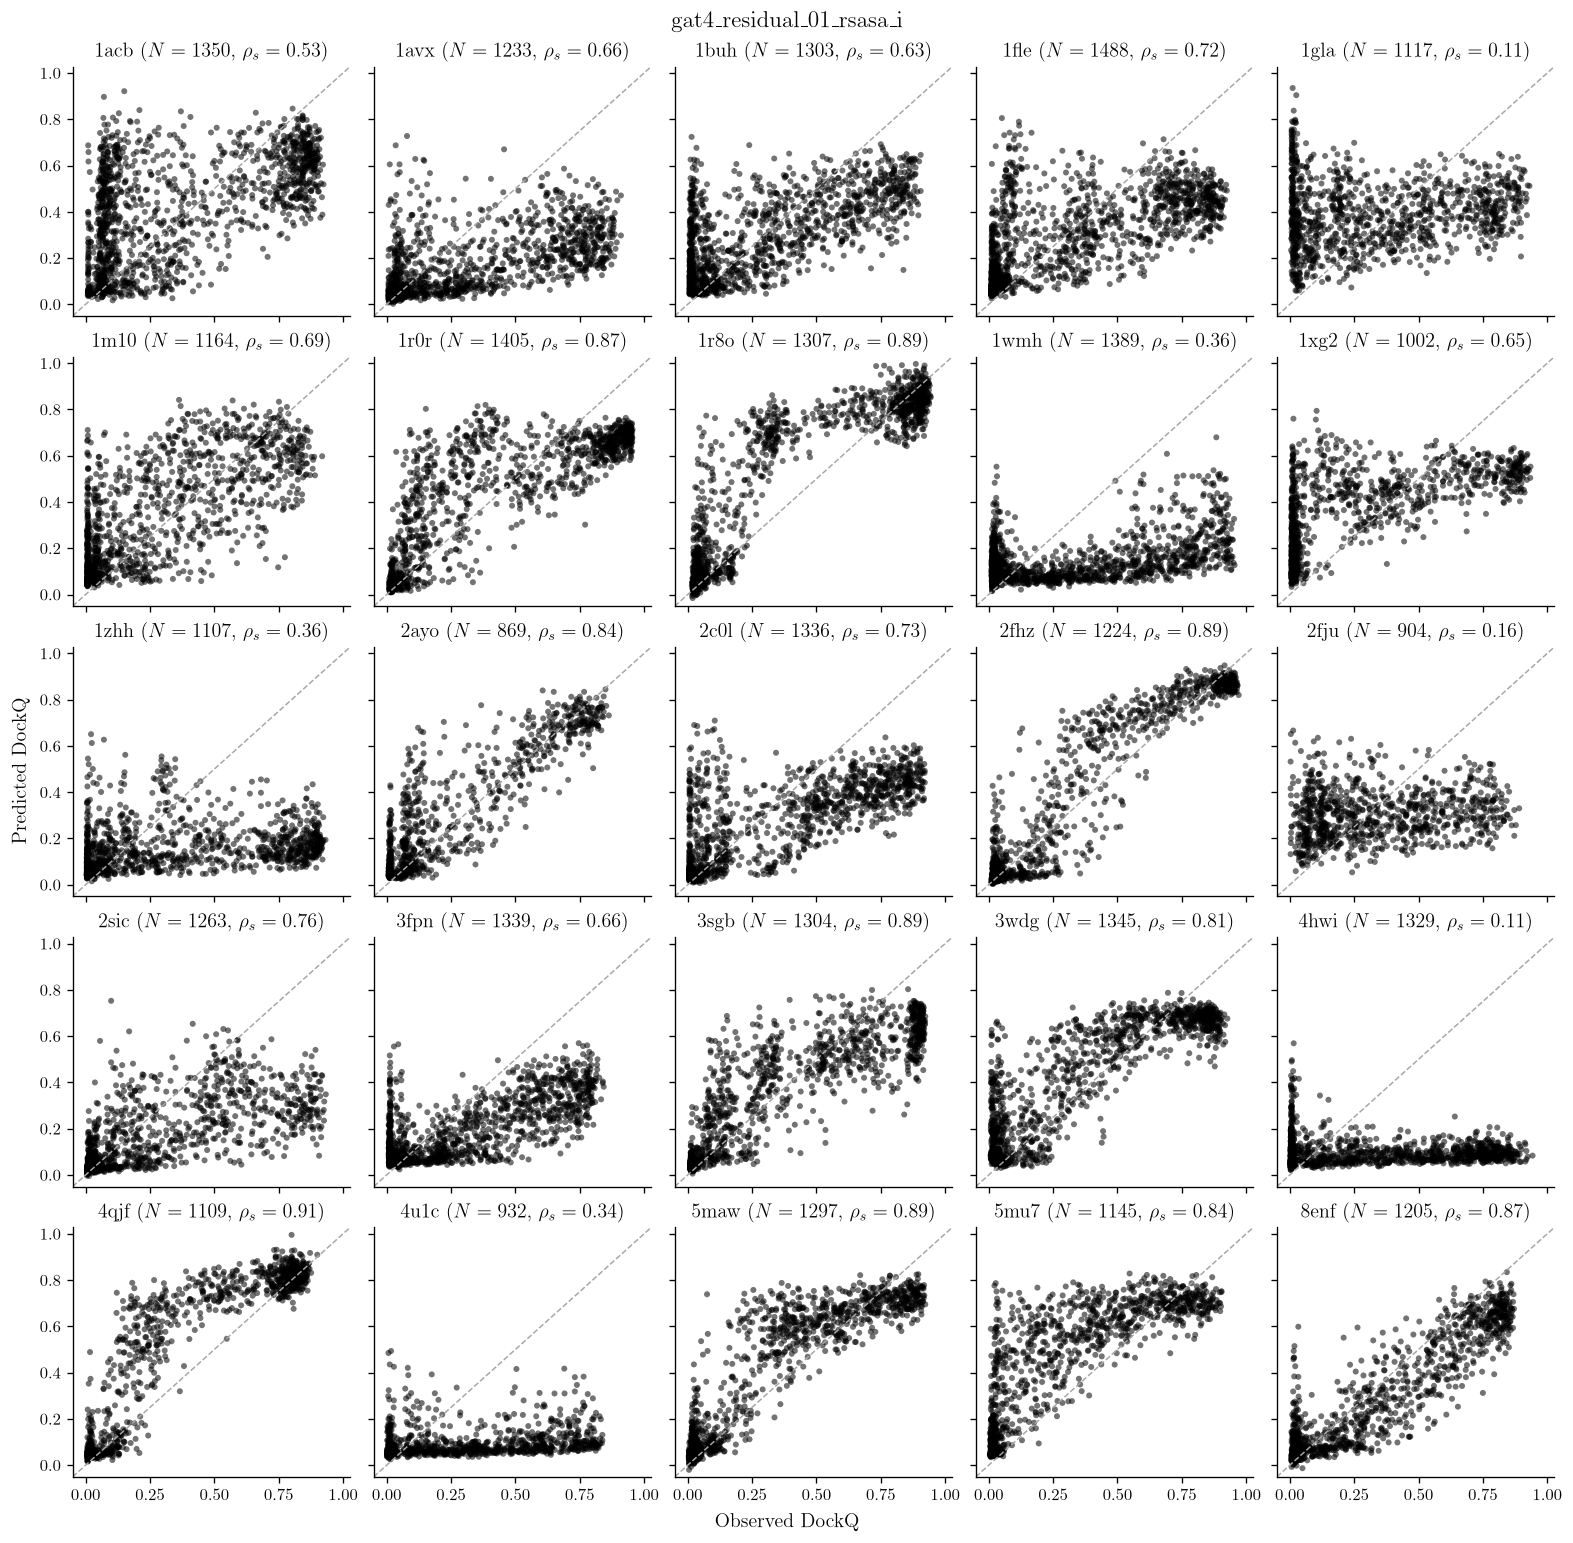

In [4]:
BEST_RUN = "gat4_residual_01_rsasa_i"

ranking = (metrics.dropna(subset=["RMSE"])
                  .sort_values("RMSE")
                  [["architecture", "feature_case", "run_name", "RMSE", "Spearman_rho"]]
                  .assign(feature_case=lambda d: d["feature_case"].str.replace("\n", " ", regex=False)))
print(f"Lowest pooled RMSE:   {ranking['run_name'].iloc[0]}")
print(f"Highest Spearman rho: {metrics.loc[metrics['Spearman_rho'].idxmax(), 'run_name']}")
print(f"Plotted below:        {BEST_RUN}")
display(ranking.style.format({"RMSE": "{:.4f}", "Spearman_rho": "{:.4f}"}).hide(axis="index"))

_ = plot_predictions_by_target(BEST_RUN)

## DockQ RMSE across the cumulative ablation

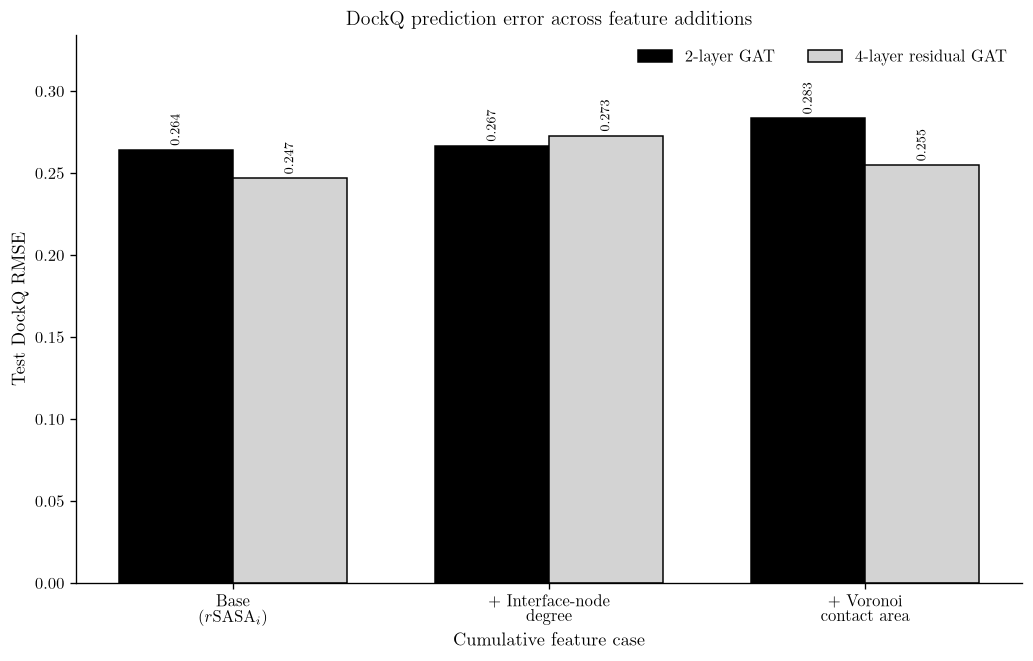

In [5]:
x = np.arange(len(STAGES))
width = 0.36
fig, ax = plt.subplots(figsize=(8.5, 5.4), constrained_layout=True)
for arch_index, (arch_key, arch_label, color) in enumerate(ARCHITECTURES):
    subset = metrics.loc[metrics["architecture_key"] == arch_key].sort_values("stage")
    positions = x + (arch_index - 0.5) * width
    ax.bar(positions, subset["RMSE"], width, color=color, edgecolor="black", linewidth=0.9, label=arch_label)
    for position, value in zip(positions, subset["RMSE"]):
        if np.isfinite(value):
            ax.text(position, value + 0.0025, f"{value:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
        else:
            ax.text(position, 0.02, "incomplete", ha="center", va="bottom", fontsize=8, rotation=90, color="0.35")
ax.set_xticks(x, [label for _, label in STAGES])
ax.set(xlabel="Cumulative feature case", ylabel="Test DockQ RMSE",
       title="DockQ prediction error across feature additions",
       ylim=(0, metrics["RMSE"].max() * 1.18))
ax.legend(ncol=2, loc="upper right")
fig.savefig(FIGURE_DIR / "ablation_dockq_rmse.pdf")
plt.show()

## Rank correlation

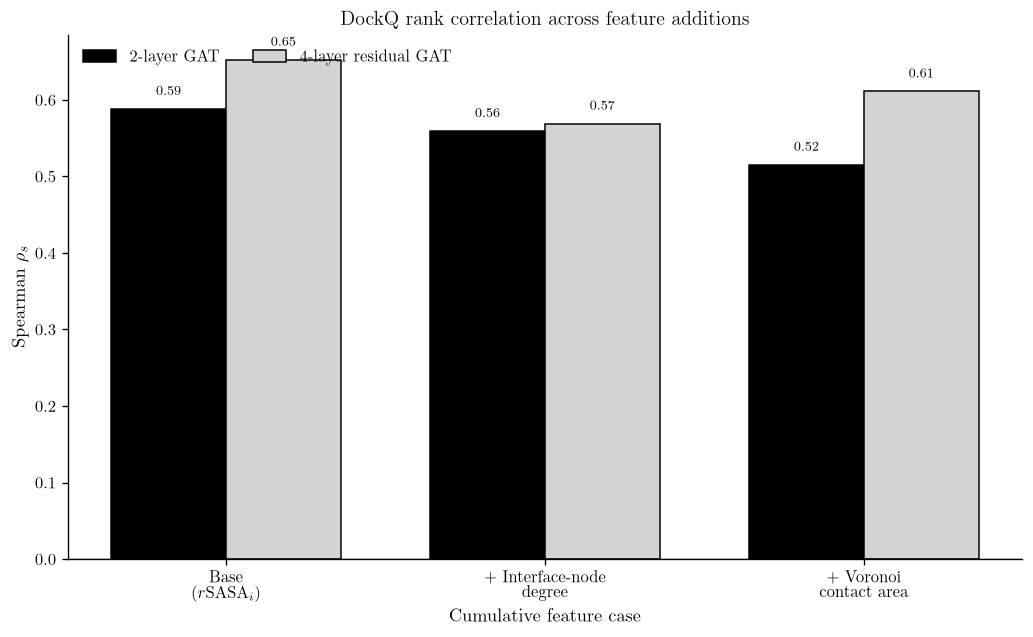

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
for arch_index, (arch_key, arch_label, color) in enumerate(ARCHITECTURES):
    subset = metrics.loc[metrics["architecture_key"] == arch_key].sort_values("stage")
    positions = x + (arch_index - 0.5) * width
    ax.bar(positions, subset["Spearman_rho"], width, color=color, edgecolor="black", linewidth=0.9, label=arch_label)
    for position, value in zip(positions, subset["Spearman_rho"]):
        if np.isfinite(value):
            ax.text(position, value + 0.015, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, [label for _, label in STAGES])
ax.set(xlabel="Cumulative feature case", ylabel=r"Spearman $\rho_s$",
       title="DockQ rank correlation across feature additions")
ax.legend(ncol=2, loc="upper left")
fig.savefig(FIGURE_DIR / "ablation_dockq_spearman.pdf")
plt.show()

## Incremental change from each added feature

Two increments are available in this sweep: adding `interface_node_degree` to the base
feature set, and then adding the `voronoi_contact_area` edge feature on top of that.

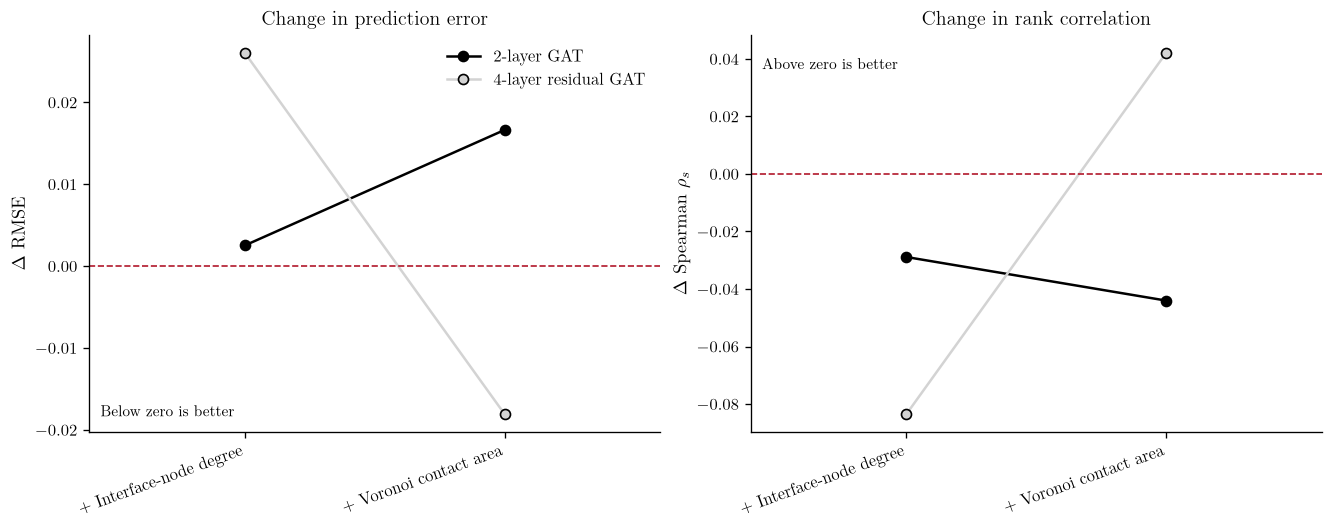

architecture,feature_case,delta_RMSE,delta_Spearman
2-layer GAT,+ Interface-node degree,+0.0025,-0.0289
2-layer GAT,+ Voronoi contact area,+0.0166,-0.0440
4-layer residual GAT,+ Interface-node degree,+0.0260,-0.0835
4-layer residual GAT,+ Voronoi contact area,-0.0181,+0.0421


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for arch_key, arch_label, color in ARCHITECTURES:
    subset = metrics.loc[metrics["architecture_key"] == arch_key].sort_values("stage")
    axes[0].plot(x, subset["RMSE"].diff(), marker="o", color=color, markeredgecolor="black", label=arch_label)
    axes[1].plot(x, subset["Spearman_rho"].diff(), marker="o", color=color, markeredgecolor="black", label=arch_label)
for ax in axes:
    ax.axhline(0, color="#b2182b", ls="--", lw=1)
    ax.set_xticks(x[1:], [label.replace("\n", " ") for _, label in STAGES][1:], rotation=20, ha="right")
    ax.set_xlim(x[1] - 0.6, x[-1] + 0.6)
axes[0].set(ylabel=r"$\Delta$ RMSE", title="Change in prediction error")
axes[1].set(ylabel=r"$\Delta$ Spearman $\rho_s$", title="Change in rank correlation")
axes[0].text(0.02, 0.04, "Below zero is better", transform=axes[0].transAxes, fontsize=9)
axes[1].text(0.02, 0.94, "Above zero is better", transform=axes[1].transAxes, va="top", fontsize=9)
axes[0].legend()
fig.savefig(FIGURE_DIR / "ablation_incremental_changes.pdf")
plt.show()

increments = (
    metrics.sort_values(["architecture_key", "stage"])
    .assign(delta_RMSE=lambda d: d.groupby("architecture_key")["RMSE"].diff(),
            delta_Spearman=lambda d: d.groupby("architecture_key")["Spearman_rho"].diff())
    .loc[lambda d: d["stage"] > 1, ["architecture", "feature_case", "delta_RMSE", "delta_Spearman"]]
    .assign(feature_case=lambda d: d["feature_case"].str.replace("\n", " ", regex=False))
)
display(increments.style.format({"delta_RMSE": "{:+.4f}", "delta_Spearman": "{:+.4f}"}, na_rep="---").hide(axis="index"))

## Validation target-loss convergence

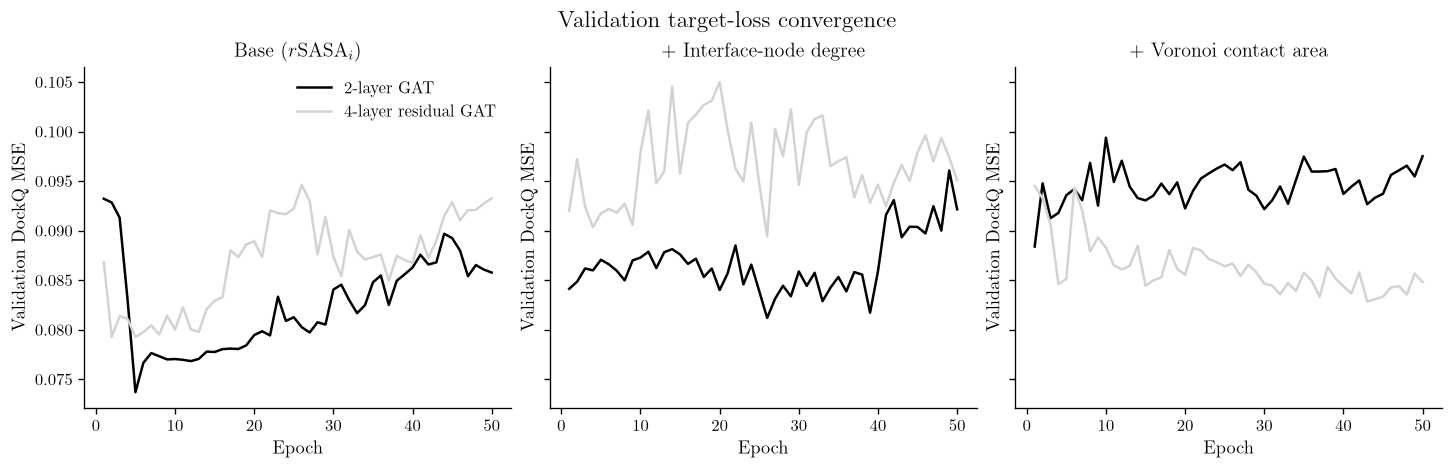

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True, constrained_layout=True)
for (stage_key, stage_label), ax in zip(STAGES, np.atleast_1d(axes).flat):
    for arch_key, arch_label, color in ARCHITECTURES:
        run_name = f"{arch_key}_{stage_key}"
        if run_name not in history_frames:
            ax.text(0.5, 0.5, f"{arch_label} incomplete", transform=ax.transAxes, ha="center", color="0.35")
            continue
        history = history_frames[run_name]
        ax.plot(history["epoch"], history["val_target_mse"], color=color, lw=1.5, label=arch_label)
    ax.set(title=stage_label.replace("\n", " "), xlabel="Epoch", ylabel="Validation DockQ MSE")
axes[0].legend()
fig.suptitle("Validation target-loss convergence", fontsize=14)
fig.savefig(FIGURE_DIR / "ablation_validation_target_mse.pdf")
plt.show()

### Full loss decomposition

The DockQ head is only one term in the training objective. These panels track the total
loss and its reconstruction components on the validation split.

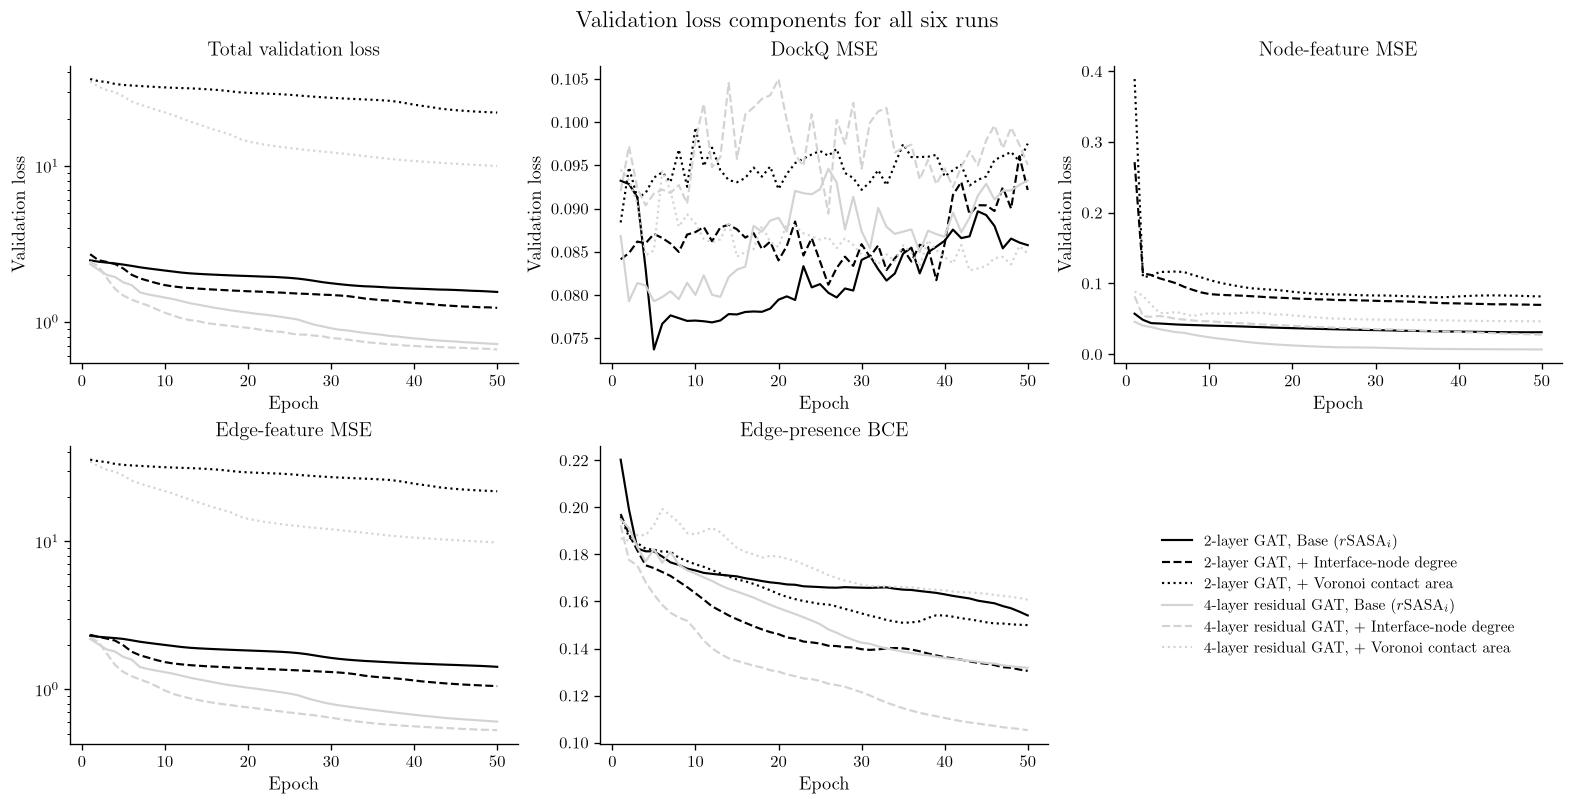

In [9]:
LOSS_TERMS = [
    ("val_loss", "Total validation loss"),
    ("val_target_mse", "DockQ MSE"),
    ("val_node_mse", "Node-feature MSE"),
    ("val_edge_attr_mse", "Edge-feature MSE"),
    ("val_edge_presence_bce", "Edge-presence BCE"),
]
LINESTYLES = {1: "-", 2: "--", 3: ":"}

fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), constrained_layout=True)
for (column, title), ax in zip(LOSS_TERMS, axes.flat):
    for arch_key, arch_label, color in ARCHITECTURES:
        for stage_index, (stage_key, stage_label) in enumerate(STAGES, start=1):
            run_name = f"{arch_key}_{stage_key}"
            if run_name not in history_frames:
                continue
            history = history_frames[run_name]
            ax.plot(history["epoch"], history[column], color=color, lw=1.3,
                    ls=LINESTYLES[stage_index],
                    label=f"{arch_label}, {stage_label}".replace("\n", " "))
    ax.set(title=title, xlabel="Epoch")
    if column in {"val_loss", "val_edge_attr_mse"}:
        ax.set_yscale("log")
for ax in axes.flat[:3]:
    ax.set_ylabel("Validation loss")
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[len(LOSS_TERMS)].set_axis_off()
axes.flat[len(LOSS_TERMS)].legend(handles, labels, loc="center", fontsize=9)
fig.suptitle("Validation loss components for all six runs", fontsize=14)
fig.savefig(FIGURE_DIR / "ablation_validation_loss_components.pdf")
plt.show()

## Target-level effect of each added feature

Each point is one held-out target. Values below the identity line improved after the
feature was added; values above it worsened.

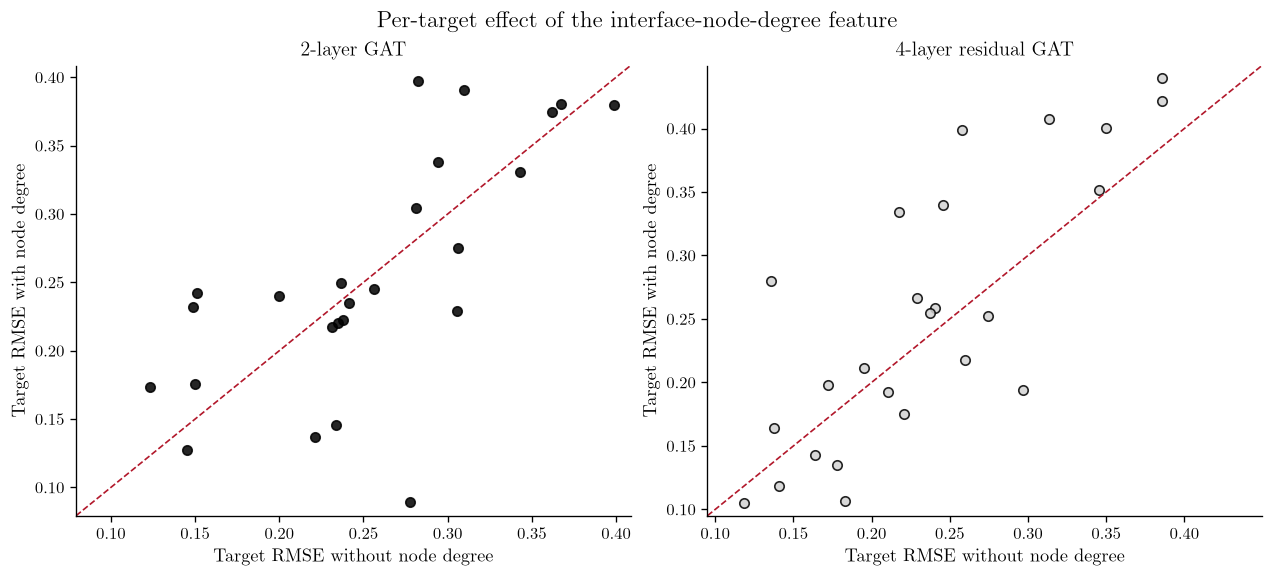

architecture,mean_target_delta_RMSE,median_target_delta_RMSE,targets_improved,targets_total,wilcoxon_p
2-layer GAT,+0.0006,-0.0064,13,25,0.771
4-layer residual GAT,+0.0189,+0.0177,10,25,0.23


In [10]:
from scipy.stats import wilcoxon

def rmse_by_target(frame):
    return (frame.assign(sq_error=(frame["predicted_target"] - frame["true_target"])**2)
                 .groupby("target_id")["sq_error"].mean().pow(0.5))

def paired_target_comparison(before_stage, after_stage, before_label, after_label, suptitle, filename):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.7), constrained_layout=True)
    rows = []
    for ax, (arch_key, arch_label, color) in zip(axes, ARCHITECTURES):
        before_run = f"{arch_key}_{before_stage}"
        after_run = f"{arch_key}_{after_stage}"
        if before_run not in prediction_frames or after_run not in prediction_frames:
            ax.text(0.5, 0.5, "incomplete", transform=ax.transAxes, ha="center", color="0.35")
            continue
        before = rmse_by_target(prediction_frames[before_run])
        after = rmse_by_target(prediction_frames[after_run])
        paired = pd.concat({before_label: before, after_label: after}, axis=1).dropna()
        limits = [paired.to_numpy().min() - 0.01, paired.to_numpy().max() + 0.01]
        ax.scatter(paired[before_label], paired[after_label], color=color, edgecolor="black", s=32, alpha=0.85)
        ax.plot(limits, limits, color="#b2182b", ls="--", lw=1)
        ax.set(xlim=limits, ylim=limits,
               xlabel=f"Target RMSE {before_label}", ylabel=f"Target RMSE {after_label}",
               title=arch_label)
        differences = paired[after_label] - paired[before_label]
        rows.append({
            "architecture": arch_label,
            "mean_target_delta_RMSE": differences.mean(),
            "median_target_delta_RMSE": differences.median(),
            "targets_improved": int((differences < 0).sum()),
            "targets_total": len(differences),
            "wilcoxon_p": wilcoxon(differences).pvalue if len(differences) > 5 else np.nan,
        })
    fig.suptitle(suptitle, fontsize=14)
    fig.savefig(FIGURE_DIR / filename)
    plt.show()
    return pd.DataFrame(rows)

node_degree_effect = paired_target_comparison(
    "01_rsasa_i", "02_plus_interface_node_degree",
    "without node degree", "with node degree",
    "Per-target effect of the interface-node-degree feature",
    "node_degree_target_rmse_comparison.pdf",
)
display(node_degree_effect.style.format(
    {"mean_target_delta_RMSE": "{:+.4f}", "median_target_delta_RMSE": "{:+.4f}", "wilcoxon_p": "{:.3g}"},
    na_rep="---").hide(axis="index"))

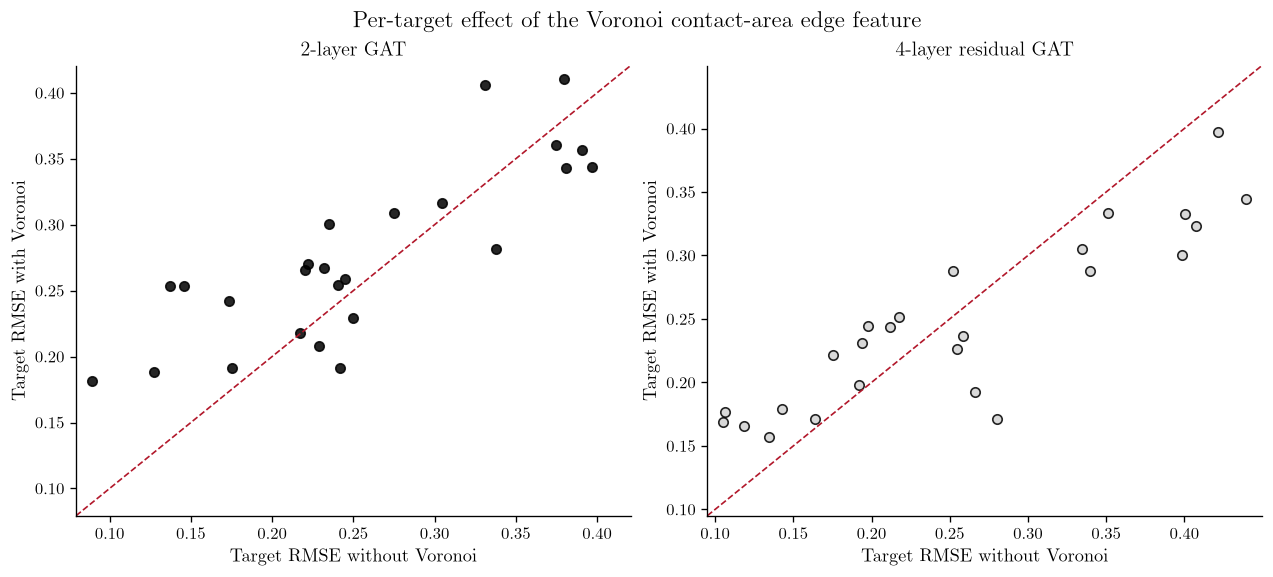

architecture,mean_target_delta_RMSE,median_target_delta_RMSE,targets_improved,targets_total,wilcoxon_p
2-layer GAT,+0.0218,+0.0159,8,25,0.071
4-layer residual GAT,-0.0087,+0.0057,12,25,0.672


In [11]:
voronoi_effect = paired_target_comparison(
    "02_plus_interface_node_degree", "03_plus_voronoi_contact_area",
    "without Voronoi", "with Voronoi",
    "Per-target effect of the Voronoi contact-area edge feature",
    "voronoi_target_rmse_comparison.pdf",
)
display(voronoi_effect.style.format(
    {"mean_target_delta_RMSE": "{:+.4f}", "median_target_delta_RMSE": "{:+.4f}", "wilcoxon_p": "{:.3g}"},
    na_rep="---").hide(axis="index"))

### Per-target RMSE for all six runs

A compact view of which targets dominate the pooled error, and whether the ranking of
targets is stable across architectures and feature cases.

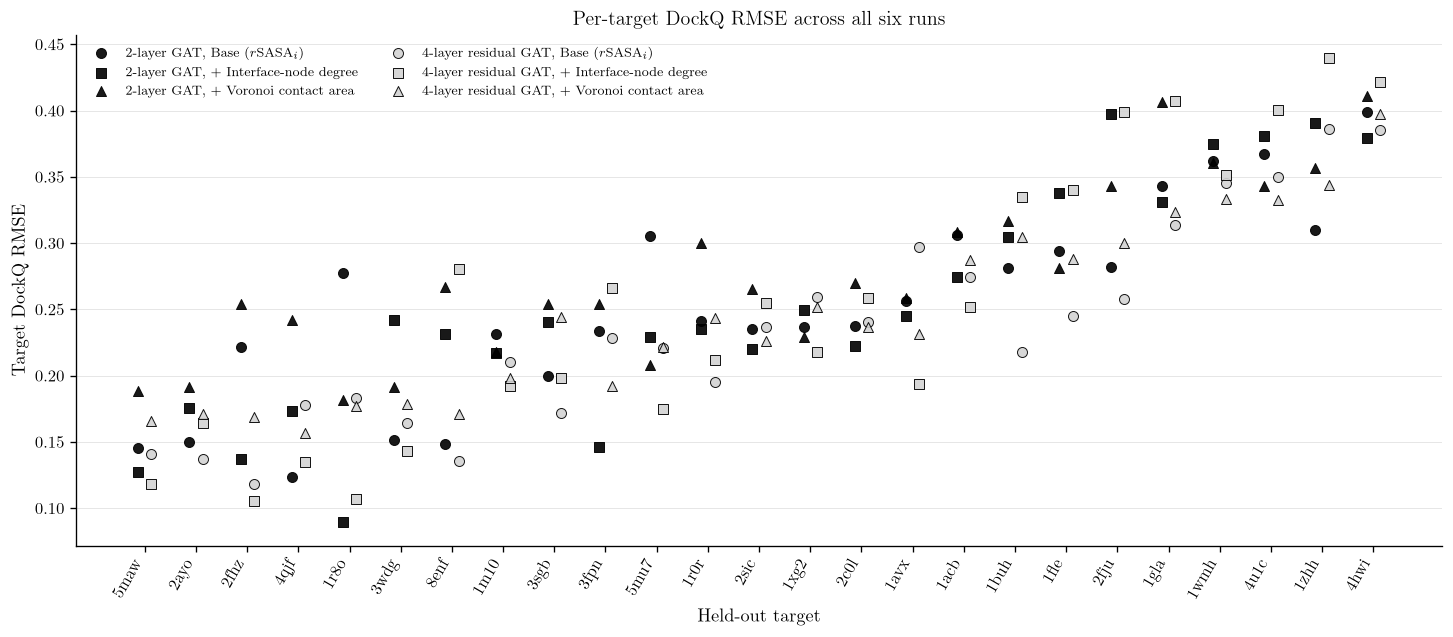

In [12]:
per_target = pd.DataFrame({
    run_name: rmse_by_target(frame) for run_name, frame in prediction_frames.items()
})
ordered_runs = [f"{arch_key}_{stage_key}"
                for arch_key, _, _ in ARCHITECTURES
                for stage_key, _ in STAGES
                if f"{arch_key}_{stage_key}" in per_target.columns]
per_target = per_target[ordered_runs]
order = per_target.mean(axis=1).sort_values().index
per_target = per_target.loc[order]

fig, ax = plt.subplots(figsize=(12, 5.2), constrained_layout=True)
positions = np.arange(len(per_target))
STAGE_MARKERS = {1: "o", 2: "s", 3: "^"}
for arch_index, (arch_key, arch_label, color) in enumerate(ARCHITECTURES):
    for stage_index, (stage_key, stage_label) in enumerate(STAGES, start=1):
        run_name = f"{arch_key}_{stage_key}"
        if run_name not in per_target.columns:
            continue
        offset = (arch_index - 0.5) * 0.26
        ax.scatter(positions + offset, per_target[run_name], s=36, marker=STAGE_MARKERS[stage_index],
                   color=color, edgecolor="black", linewidth=0.6, alpha=0.9,
                   label=f"{arch_label}, {stage_label}".replace("\n", " "))
ax.set_xticks(positions, [tex_safe(str(t)) for t in per_target.index], rotation=60, ha="right")
ax.set(xlabel="Held-out target", ylabel="Target DockQ RMSE",
       title="Per-target DockQ RMSE across all six runs")
ax.grid(axis="y", color="0.9", lw=0.6)
ax.set_axisbelow(True)
ax.legend(ncol=2, fontsize=8, loc="upper left")
fig.savefig(FIGURE_DIR / "per_target_rmse_all_runs.pdf")
plt.show()

## Autoencoder reconstruction quality

These runs also export decoder metrics (`reconstruction_summary.csv` and
`reconstruction_by_target.csv`), which the DockQ-only analysis above does not touch. The
panels below check whether the extra features help or hurt the reconstruction half of the
objective. Note that `drsasa` was not part of this sweep, so its columns are empty.

In [13]:
recon_rows = []
for arch_key, arch_label, _ in ARCHITECTURES:
    for stage_index, (stage_key, stage_label) in enumerate(STAGES, start=1):
        run_name = f"{arch_key}_{stage_key}"
        if run_name not in recon_summary_frames:
            continue
        row = recon_summary_frames[run_name].iloc[0].to_dict()
        row.update(architecture=arch_label, architecture_key=arch_key,
                   stage=stage_index, feature_case=stage_label, run_name=run_name)
        recon_rows.append(row)
reconstruction = pd.DataFrame(recon_rows)

RECON_METRICS = [
    ("aa_identity_accuracy_pct", f"AA identity accuracy ({PCT})", "{:.2f}", False),
    ("chain_accuracy_pct", f"Chain accuracy ({PCT})", "{:.2f}", False),
    ("interface_node_accuracy_pct", f"Interface-node accuracy ({PCT})", "{:.2f}", False),
    ("rsasa_i_mae", r"$r$SASA$_i$ MAE", "{:.4f}", True),
    ("ca_dist_mae_angstrom", rf"C$\alpha$ distance MAE ({ANGSTROM})", "{:.3f}", True),
    ("edge_f1_pct", f"Interface-edge F1 ({PCT})", "{:.2f}", False),
]

display(reconstruction[[
    "architecture", "feature_case", "graphs", "node_feature_mse", "edge_feature_mse",
    "aa_identity_accuracy_pct", "chain_accuracy_pct", "interface_node_accuracy_pct",
    "rsasa_i_mae", "ca_dist_mae_angstrom",
    "edge_recall_pct", "edge_precision_pct", "edge_f1_pct",
]].assign(feature_case=lambda d: d["feature_case"].str.replace("\n", " ", regex=False)).style.format({
    "node_feature_mse": "{:.4f}", "edge_feature_mse": "{:.4f}",
    "aa_identity_accuracy_pct": "{:.2f}", "chain_accuracy_pct": "{:.2f}",
    "interface_node_accuracy_pct": "{:.2f}", "rsasa_i_mae": "{:.4f}",
    "ca_dist_mae_angstrom": "{:.3f}", "edge_recall_pct": "{:.2f}",
    "edge_precision_pct": "{:.2f}", "edge_f1_pct": "{:.2f}",
}, na_rep="---").hide(axis="index"))

architecture,feature_case,graphs,node_feature_mse,edge_feature_mse,aa_identity_accuracy_pct,chain_accuracy_pct,interface_node_accuracy_pct,rsasa_i_mae,ca_dist_mae_angstrom,edge_recall_pct,edge_precision_pct,edge_f1_pct
2-layer GAT,Base ($r$SASA$_i$),30466,0.0309,1.4398,50.50,99.87,97.87,0.0337,1.365,13.46,94.42,23.56
2-layer GAT,+ Interface-node degree,30466,0.0651,1.1055,22.05,99.64,95.76,0.4064,1.144,24.20,94.41,38.53
2-layer GAT,+ Voronoi contact area,30466,0.0744,20.6861,25.61,98.27,95.36,0.4697,1.586,8.26,95.34,15.21
4-layer residual GAT,Base ($r$SASA$_i$),30466,0.0064,0.5972,97.47,99.95,98.85,0.0588,0.865,27.78,95.70,43.06
4-layer residual GAT,+ Interface-node degree,30466,0.0259,0.5367,68.29,99.90,98.27,0.1403,0.804,46.54,96.39,62.77
4-layer residual GAT,+ Voronoi contact area,30466,0.0439,9.2396,44.63,94.69,95.78,0.2772,1.482,9.97,96.98,18.08


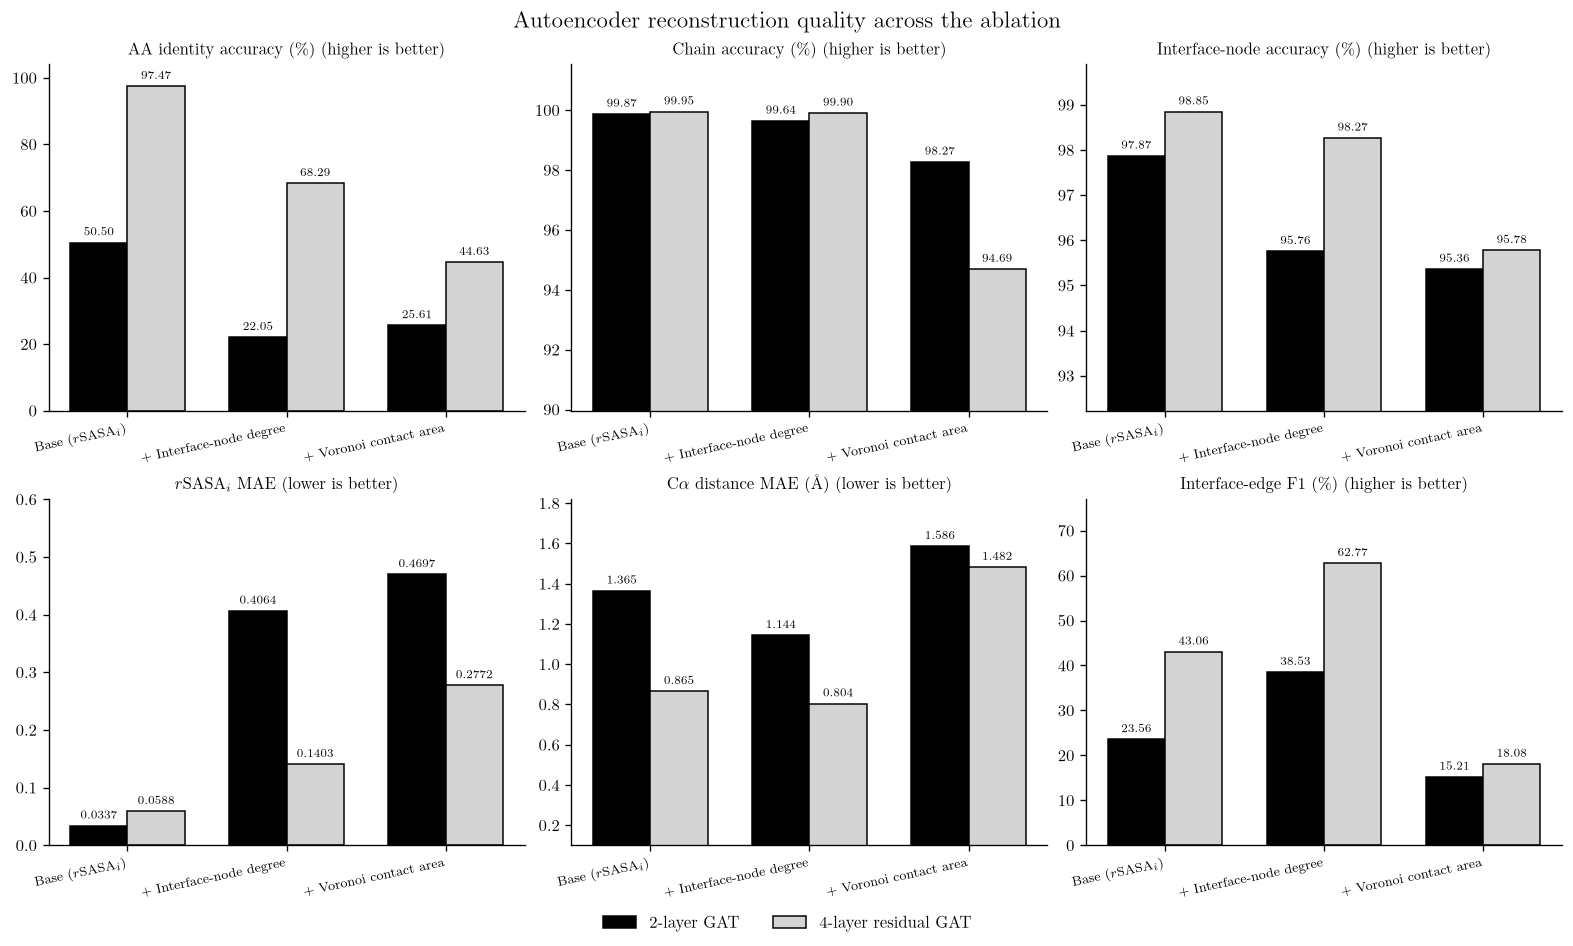

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.8), constrained_layout=True)
for (column, label, fmt, lower_is_better), ax in zip(RECON_METRICS, axes.flat):
    values = reconstruction[column].astype(float)
    for arch_index, (arch_key, arch_label, color) in enumerate(ARCHITECTURES):
        subset = reconstruction.loc[reconstruction["architecture_key"] == arch_key].sort_values("stage")
        positions = x + (arch_index - 0.5) * width
        ax.bar(positions, subset[column], width, color=color, edgecolor="black", linewidth=0.9, label=arch_label)
        for position, value in zip(positions, subset[column]):
            if np.isfinite(value):
                ax.annotate(fmt.format(value), (position, value), textcoords="offset points",
                            xytext=(0, 3), ha="center", va="bottom", fontsize=7)
    low, high = values.min(), values.max()
    span = (high - low) or max(abs(high), 1.0) * 0.2
    top = high + 0.30 * span
    if column.endswith("_pct"):
        top = min(top, 104.0)
    ax.set_ylim(max(0.0, low - 0.9 * span), top)
    ax.set_xticks(x, [label_.replace("\n", " ") for _, label_ in STAGES], rotation=12, ha="right", fontsize=8)
    ax.set_title(label + ("  (lower is better)" if lower_is_better else "  (higher is better)"), fontsize=10)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=2, fontsize=10)
fig.suptitle("Autoencoder reconstruction quality across the ablation", fontsize=14)
fig.savefig(FIGURE_DIR / "ablation_reconstruction_metrics.pdf")
plt.show()

### Per-target spread of the reconstruction metrics

Bars above are pooled over every test graph. These box plots show how much the
reconstruction quality varies between the 25 held-out targets.

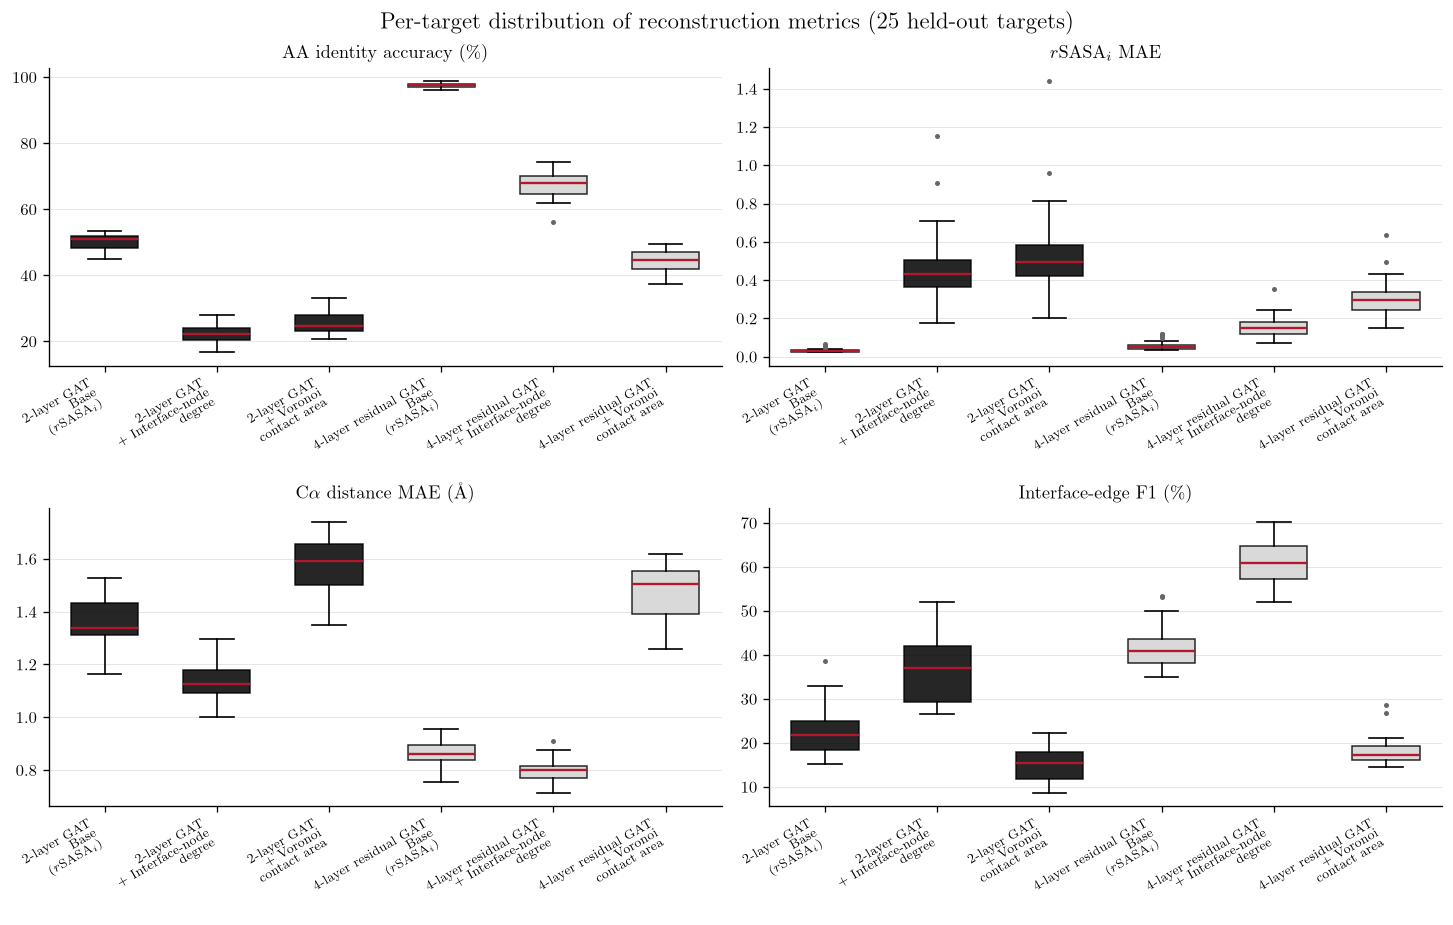

In [15]:
BOX_METRICS = [
    ("aa_identity_accuracy_pct", f"AA identity accuracy ({PCT})"),
    ("rsasa_i_mae", r"$r$SASA$_i$ MAE"),
    ("ca_dist_mae_angstrom", rf"C$\alpha$ distance MAE ({ANGSTROM})"),
    ("edge_f1_pct", f"Interface-edge F1 ({PCT})"),
]
box_runs = [f"{arch_key}_{stage_key}"
            for arch_key, _, _ in ARCHITECTURES
            for stage_key, _ in STAGES
            if f"{arch_key}_{stage_key}" in recon_target_frames]
box_labels = [f"{arch_label}\n{stage_label}".replace("\n", " ", 0)
              for arch_key, arch_label, _ in ARCHITECTURES
              for stage_key, stage_label in STAGES
              if f"{arch_key}_{stage_key}" in recon_target_frames]

fig, axes = plt.subplots(2, 2, figsize=(12, 7.6), constrained_layout=True)
for (column, label), ax in zip(BOX_METRICS, axes.flat):
    data = [recon_target_frames[run_name][column].dropna().to_numpy() for run_name in box_runs]
    colors = [color for _, _, color in ARCHITECTURES for _ in STAGES]
    boxes = ax.boxplot(data, patch_artist=True, widths=0.6,
                       medianprops={"color": "#b2182b", "lw": 1.4},
                       flierprops={"marker": "o", "ms": 3, "mfc": "0.4", "mec": "none"})
    for patch, color in zip(boxes["boxes"], colors):
        patch.set(facecolor=color, edgecolor="black", linewidth=0.9, alpha=0.85)
    ax.set_xticks(np.arange(1, len(box_runs) + 1), box_labels, rotation=30, ha="right", fontsize=7.5)
    ax.set_title(label, fontsize=11)
    ax.grid(axis="y", color="0.9", lw=0.6)
    ax.set_axisbelow(True)
fig.suptitle("Per-target distribution of reconstruction metrics (25 held-out targets)", fontsize=14)
fig.savefig(FIGURE_DIR / "reconstruction_per_target_distributions.pdf")
plt.show()

## Reading the plots

- Lower RMSE and higher Spearman correlation are better.
- Stage 1 is not a bare baseline: it already carries `aa_type`, `chain`, `interface_nodes`
  and `rsasa_i`. The two increments in this sweep are `interface_node_degree` (node) and
  `voronoi_contact_area` (edge).
- The incremental panels isolate the change at each cumulative step, although each model
  was trained independently, so a step can move for reasons unrelated to the feature.
- The paired per-target plots are the most direct view of whether a feature helps
  consistently or only for particular targets. The Wilcoxon signed-rank $p$-value is a
  paired test over the 25 targets and is reported without multiple-testing correction.
- The reconstruction section covers the autoencoder half of the objective, which the DockQ
  metrics say nothing about; a feature that leaves DockQ unchanged can still shift
  reconstruction quality.
- All 6 runs use the same 25 held-out targets and 30{,}466 test models, so the comparisons
  are paired throughout.
- Figures are saved as PDFs under `full_feature_ablation_lr5e-6/analysis_figures/`.